In [6]:
from google.colab import files
uploaded = files.upload()

Saving netflix_user_behavior_churn_50000.csv to netflix_user_behavior_churn_50000.csv


In [7]:
import pandas as pd

df = pd.read_csv('netflix_user_behavior_churn_50000.csv')

df.head()

,user_id,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,recommendation_source,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login,churned
0,N00001,33,Male,Europe,Basic,Credit Card,Smart TV,38,Comedy,Afternoon,Trending,1,259,4,79,4,4,48,3,0
1,N00002,41,Male,Africa,Premium,Credit Card,Tablet,49,Comedy,Evening,Search,1,164,4,69,4,4,32,30,0
2,N00003,28,Female,Europe,Standard,Gift Card,Laptop,20,Drama,Evening,Ads,1,304,5,75,4,3,31,5,1
3,N00004,40,Female,North America,Basic,Credit Card,Mobile,19,Action,Evening,Algorithm,1,145,6,79,4,4,39,38,0
4,N00005,54,Male,Europe,Standard,Paypal,Mobile,51,Romance,Evening,Friend,3,108,1,58,5,4,50,5,0


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   user_id                          50000 non-null  object
 1   age                              50000 non-null  int64 
 2   gender                           50000 non-null  object
 3   region                           50000 non-null  object
 4   subscription_type                50000 non-null  object
 5   payment_method                   50000 non-null  object
 6   primary_device                   50000 non-null  object
 7   account_age_months               50000 non-null  int64 
 8   favorite_genre                   50000 non-null  object
 9   time_of_day                      50000 non-null  object
 10  recommendation_source            50000 non-null  object
 11  session_count                    50000 non-null  int64 
 12  avg_watch_time_minutes_per_week 

In [12]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
region,0
subscription_type,0
payment_method,0
primary_device,0
account_age_months,0
favorite_genre,0
time_of_day,0


In [14]:
print(df.columns)

Index(['user_id', 'age', 'gender', 'region', 'subscription_type',
       'payment_method', 'primary_device', 'account_age_months',
       'favorite_genre', 'time_of_day', 'recommendation_source',
       'session_count', 'avg_watch_time_minutes_per_week',
       'watch_sessions_per_week', 'completion_rate', 'avg_rating_given',
       'app_rating', 'recommendation_click_rate', 'days_since_last_login',
       'churned'],
      dtype='object')


In [18]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['user_id', 'age', 'gender', 'region', 'subscription_type',
       'payment_method', 'primary_device', 'account_age_months',
       'favorite_genre', 'time_of_day', 'recommendation_source',
       'session_count', 'avg_watch_time_minutes_per_week',
       'watch_sessions_per_week', 'completion_rate', 'avg_rating_given',
       'app_rating', 'recommendation_click_rate', 'days_since_last_login',
       'churned'],
      dtype='object')


In [19]:
df.duplicated().sum()

np.int64(0)

In [22]:
print(df.columns)

Index(['user_id', 'age', 'gender', 'region', 'subscription_type',
       'payment_method', 'primary_device', 'account_age_months',
       'favorite_genre', 'time_of_day', 'recommendation_source',
       'session_count', 'avg_watch_time_minutes_per_week',
       'watch_sessions_per_week', 'completion_rate', 'avg_rating_given',
       'app_rating', 'recommendation_click_rate', 'days_since_last_login',
       'churned'],
      dtype='object')


In [23]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

print(df.columns)

Index(['user_id', 'age', 'gender', 'region', 'subscription_type',
       'payment_method', 'primary_device', 'account_age_months',
       'favorite_genre', 'time_of_day', 'recommendation_source',
       'session_count', 'avg_watch_time_minutes_per_week',
       'watch_sessions_per_week', 'completion_rate', 'avg_rating_given',
       'app_rating', 'recommendation_click_rate', 'days_since_last_login',
       'churned'],
      dtype='object')


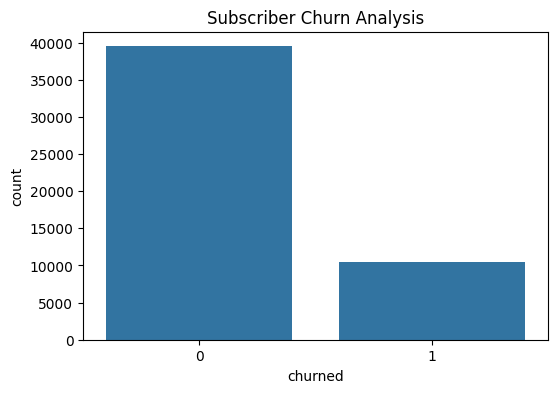

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='churned')
plt.title('Subscriber Churn Analysis')
plt.show()

In [31]:
plan_churn=pd.crosstab(df['subscription_type'],df['churned'])

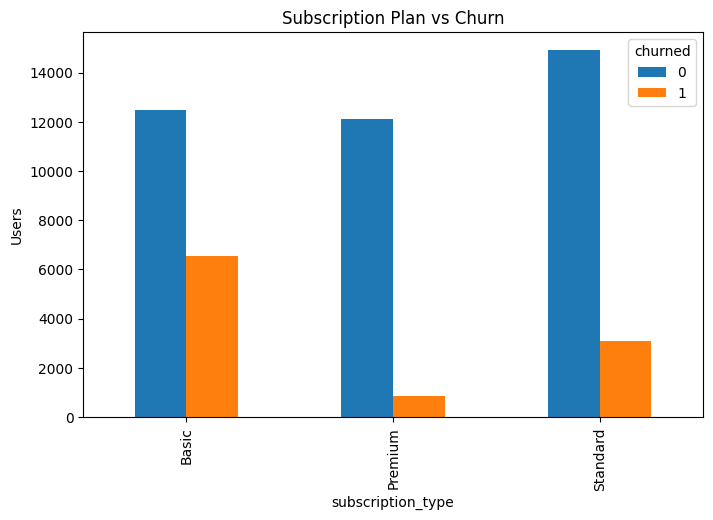

In [32]:
plan_churn.plot(kind='bar',figsize=(8,5))
plt.title('Subscription Plan vs Churn')
plt.ylabel('Users')
plt.show()

In [33]:
df['favorite_genre'].value_counts()

,count
favorite_genre,
Comedy,10000
Drama,9000
Action,8000
Documentary,7000
Sci-Fi,6500
Horror,5000
Romance,4500


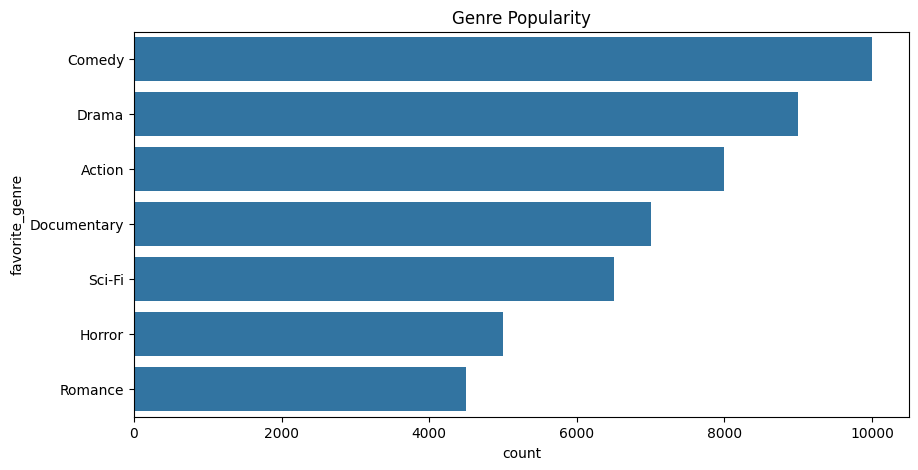

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(y='favorite_genre',data=df,order=df['favorite_genre'].value_counts().index)
plt.title('Genre Popularity')
plt.show()

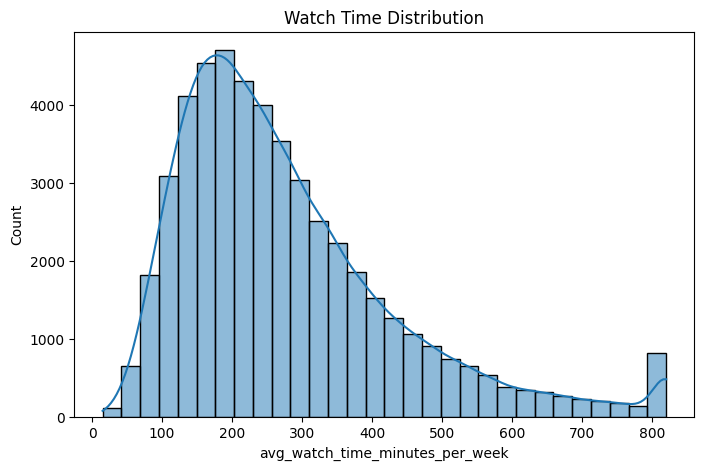

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['avg_watch_time_minutes_per_week'],bins=30,kde=True)
plt.title('Watch Time Distribution')
plt.show()



In [49]:
def engagement_level(x):
  if x<300:
    return 'Low'
  elif x<700:
    return 'Medium'
  else:
    return 'High'
df['engagement_level']=df['avg_watch_time_minutes_per_week'].apply(engagement_level)
print(df['engagement_level'].value_counts())

engagement_level
Low       32704
Medium    15860
High       1436
Name: count, dtype: int64


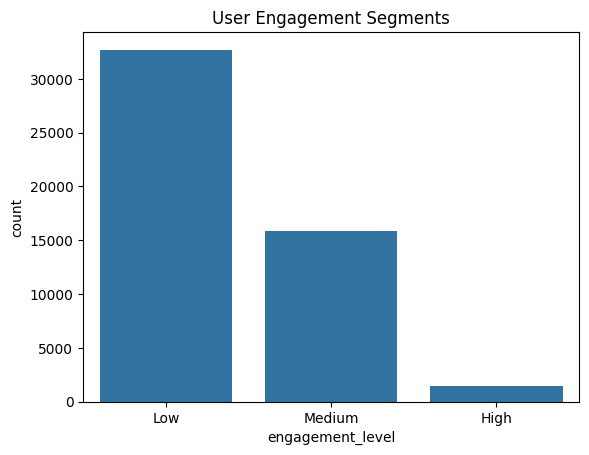

In [52]:
sns.countplot(data=df,x='engagement_level')
plt.title('User Engagement Segments')
plt.show()

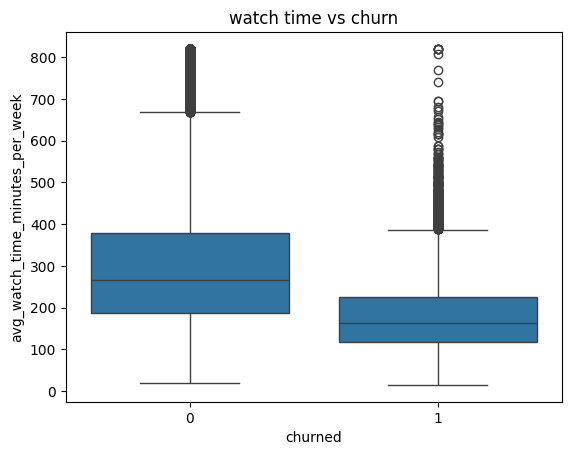

In [53]:
sns.boxplot(data=df,x='churned',y='avg_watch_time_minutes_per_week'
)
plt.title('watch time vs churn')
plt.show()


In [54]:
df.groupby('churned')['avg_watch_time_minutes_per_week'].mean()

,avg_watch_time_minutes_per_week
churned,
0,303.642076
1,181.301905
